<a href="https://colab.research.google.com/github/MRMRAC/2025-NN/blob/main/%D0%9A%D0%9E%D0%9F%D0%98%D0%AF%D0%94%D0%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Реализация многослойного автокодировщика для цветного изображения из датасета CIFAR-10**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
torch.manual_seed(42)

In [ ]:
stacked_encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, 512), nn.ReLU(),
    nn.Linear(512, 128), nn.ReLU(),
    nn.Linear(128, 32), nn.ReLU(),
)
stacked_decoder = nn.Sequential(
    nn.Linear(32, 128), nn.ReLU(),
    nn.Linear(128, 512), nn.ReLU(),
    nn.Linear(512, 3 * 32 * 32), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(3, 32, 32))
)
stacked_ae = nn.Sequential(stacked_encoder, stacked_decoder).to(device)

In [ ]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.CIFAR10(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [45_000, 5_000])

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


In [ ]:
from torch.utils.data import Dataset

class AutoencoderDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, _ = self.base_dataset[idx]
        return x, x

train_loader = DataLoader(AutoencoderDataset(train_data), batch_size=64,
                          shuffle=True)
valid_loader = DataLoader(AutoencoderDataset(valid_data), batch_size=64)
test_loader = DataLoader(AutoencoderDataset(test_data), batch_size=64)

In [ ]:
!pip install torchmetrics
import torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.7 MB/s eta 0:00:00


In [ ]:
def train(model, optimizer, loss_fn, rmse_fn, train_loader, valid_loader, n_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_rmse": [], "val_rmse": []}

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0
        train_rmse = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_rmse += rmse_fn(y_pred, y_batch).item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        train_rmse /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_rmse = 0.0

        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_rmse += rmse_fn(y_pred, y_batch).item() * X_batch.size(0)

        val_loss /= len(valid_loader.dataset)
        val_rmse /= len(valid_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)

        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    return history

In [ ]:
optimizer = torch.optim.NAdam(stacked_ae.parameters(), lr=0.001)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train(stacked_ae, optimizer, mse, rmse, train_loader, valid_loader,
                n_epochs=10)

Epoch 1/10, Train Loss: 0.0228, Val Loss: 0.0237
Epoch 2/10, Train Loss: 0.0218, Val Loss: 0.0230
Epoch 3/10, Train Loss: 0.0211, Val Loss: 0.0221
Epoch 4/10, Train Loss: 0.0206, Val Loss: 0.0201
Epoch 5/10, Train Loss: 0.0198, Val Loss: 0.0200
Epoch 6/10, Train Loss: 0.0192, Val Loss: 0.0194
Epoch 7/10, Train Loss: 0.0187, Val Loss: 0.0188
Epoch 8/10, Train Loss: 0.0182, Val Loss: 0.0187
Epoch 9/10, Train Loss: 0.0180, Val Loss: 0.0189
Epoch 10/10, Train Loss: 0.0179, Val Loss: 0.0186


In [ ]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0).cpu())
    plt.axis("off")

def plot_reconstructions(model, images, n_images=5):
    images = images[:n_images]
    with torch.no_grad():
        y_pred = model(images.to(device))
    if isinstance(y_pred, tuple):
        y_pred = y_pred.output
    fig = plt.figure(figsize=(len(images) * 1.5, 3))
    for idx in range(len(images)):
        plt.subplot(2, len(images), 1 + idx)
        plot_image(images[idx])
        plt.subplot(2, len(images), 1 + len(images) + idx)
        plot_image(y_pred[idx])

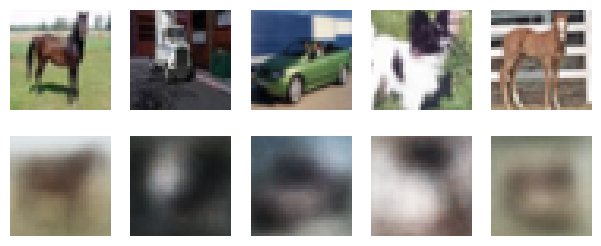

In [ ]:
X_valid = torch.stack([x for x, _ in valid_data])
plot_reconstructions(stacked_ae, X_valid)

plt.show()

**1.1 Для чего необходимы функции активации?**

Функции активации в автокодировщике необходимы для аппроксимации сложных зависимостей и выделения значимых признаков в данных. Это позволяет получить физически корректное выходное изображение.

ReLU (в энкодере и декодере):

* Позволяет сети захватить важные шаблоны(постепенно уменьшая размер и сложность данных) и выделить общие закономерности в изображениях (края, текстуры, объекты)
* Решает проблему затухающих градиентов
* Создает разреженные представления, при которых сеть активирует небольшое количество нейронов. Это снижает сложность модели и даёт сети фиксировать только наиболее важные функции.

Sigmoid (на выходе декодера):
* Ограничивает значения пикселей реконструированного изображения диапазоном [0, 1], что соответствует нормализованным входным данным и гарантирует корректность выходного тензора.

**1.2 Как модель воссоздаёт фото по неполным данным:**


1. Сжатие и выделение признаков (Энкодер)

 Модель принудительно сжимает входное изображение в компактный латентный вектор. В процессе обучения энкодер учится отбрасывать шум и избыточную информацию, сохраняя только существенные признаки (края, текстуры, структуру объекта).

2. Обучение распределению данных

 В ходе минимизации функции потерь (MSE) модель изучает многообразие натуральных изображений. Она запоминает не конкретные пиксели, а закономерности того, как выглядят объекты (например, что у машины есть колеса, а у лица глаза).

3. Генерация на основе признаков (Декодер)

 Декодер использует сжатый латентный вектор как «инструкцию». Поскольку модель выучила распределение данных, она способна развернуть компактное представление обратно в полное изображение, восполняя недостающие детали на основе выученных закономерностей.

**2. Построить GAN, взять из ноутбука, построить график изменения функции потерь по каждой эпохе**

In [ ]:
torch.manual_seed(42)

codings_dim = 32
generator = nn.Sequential(
    nn.Linear(codings_dim, 256), nn.ReLU(),
    nn.Linear(256, 512), nn.ReLU(),
    nn.Linear(512, 1024), nn.ReLU(),
    nn.Linear(1024, 3 * 32 * 32), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(3, 32, 32))).to(device)
discriminator = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, 1024), nn.ReLU(),
    nn.Linear(1024, 512), nn.ReLU(),
    nn.Linear(512, 256), nn.ReLU(),
    nn.Linear(256, 1), nn.Sigmoid()).to(device)

In [ ]:
def plot_multiple_images(images, n_cols):
    n_rows = (len(images) - 1) // n_cols + 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for i, ax in enumerate(axes):
        if i < len(images):
            img = images[i].cpu().permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)
            ax.imshow(img)
        ax.axis("off")
    plt.tight_layout()

In [ ]:
def train_gan(generator, discriminator, train_loader, codings_dim, n_epochs=20,
              g_lr=1e-3, d_lr=5e-4):
    criterion = nn.BCELoss()
    generator_opt = torch.optim.NAdam(generator.parameters(), lr=g_lr)
    discriminator_opt = torch.optim.NAdam(discriminator.parameters(), lr=d_lr)
    #Списки для отслеживания потерь по эпохам
    generator_losses = []
    discriminator_losses = []
    for epoch in range(n_epochs):
        print(f"Epoch {epoch + 1}/{n_epochs}", end="")
        epoch_generator_loss = 0.0
        epoch_discriminator_loss = 0.0
        num_batches = 0
        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            pred_real = discriminator(real_images)
            batch_size = real_images.size(0)
            ones = torch.ones(batch_size, 1, device=device)
            real_loss = criterion(pred_real, ones)
            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings).detach()
            pred_fake = discriminator(fake_images)
            zeros = torch.zeros(batch_size, 1, device=device)
            fake_loss = criterion(pred_fake, zeros)
            discriminator_loss = real_loss + fake_loss
            discriminator_opt.zero_grad()
            discriminator_loss.backward()
            discriminator_opt.step()

            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings)
            for p in discriminator.parameters():
                p.requires_grad = False
            pred_fake = discriminator(fake_images)
            generator_loss = criterion(pred_fake, ones)
            generator_opt.zero_grad()
            generator_loss.backward()
            generator_opt.step()
            for p in discriminator.parameters():
                p.requires_grad = True
            #Накопление потерь за эпоху
            epoch_generator_loss += generator_loss.item()
            epoch_discriminator_loss += discriminator_loss.item()
            num_batches += 1
        #Усреднение потерь за эпоху
        avg_generator_loss = epoch_generator_loss / num_batches
        avg_discriminator_loss = epoch_discriminator_loss / num_batches

        generator_losses.append(avg_generator_loss)
        discriminator_losses.append(avg_discriminator_loss)

        print(f" | discriminator loss: {avg_discriminator_loss:.4f}", end="")
        print(f" | generator loss: {avg_generator_loss:.4f}")
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            plot_multiple_images(fake_images.detach(), 8)
            plt.show()

    return generator_losses, discriminator_losses

Epoch 1/20 | discriminator loss: 1.3898 | generator loss: 0.7373


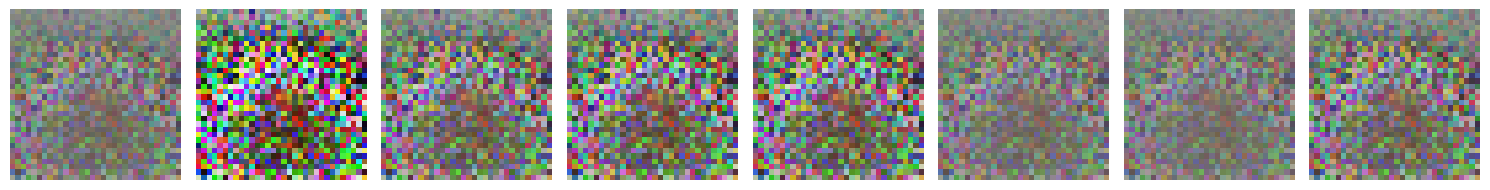

Epoch 2/20 | discriminator loss: 1.3906 | generator loss: 0.7151
Epoch 3/20 | discriminator loss: 1.3740 | generator loss: 0.7189
Epoch 4/20 | discriminator loss: 1.3810 | generator loss: 0.7874
Epoch 5/20 | discriminator loss: 1.3757 | generator loss: 0.7939
Epoch 6/20 | discriminator loss: 1.3405 | generator loss: 0.7927
Epoch 7/20 | discriminator loss: 1.3797 | generator loss: 0.7034
Epoch 8/20 | discriminator loss: 1.3815 | generator loss: 0.6998
Epoch 9/20 | discriminator loss: 1.3863 | generator loss: 0.6937
Epoch 10/20 | discriminator loss: 1.3863 | generator loss: 0.6932
Epoch 11/20 | discriminator loss: 1.3863 | generator loss: 0.6931


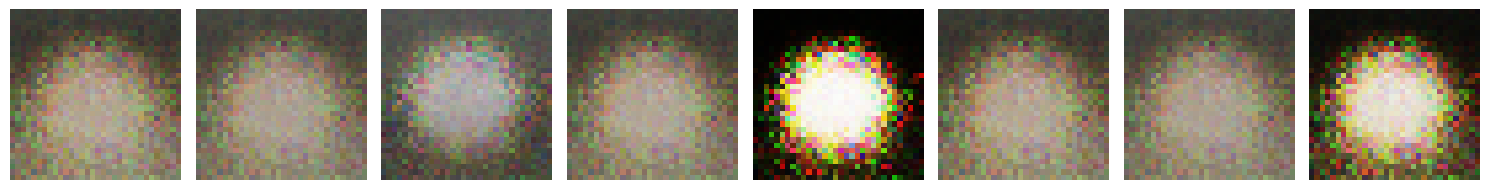

Epoch 12/20 | discriminator loss: 1.3863 | generator loss: 0.6931
Epoch 13/20 | discriminator loss: 1.3863 | generator loss: 0.6931
Epoch 14/20 | discriminator loss: 1.3863 | generator loss: 0.6931
Epoch 15/20 | discriminator loss: 1.3863 | generator loss: 0.6931
Epoch 16/20 | discriminator loss: 1.3863 | generator loss: 0.6931
Epoch 17/20 | discriminator loss: 1.3863 | generator loss: 0.6931
Epoch 18/20 | discriminator loss: 1.3863 | generator loss: 0.6931
Epoch 19/20 | discriminator loss: 1.3863 | generator loss: 0.6931
Epoch 20/20 | discriminator loss: 1.3863 | generator loss: 0.6931


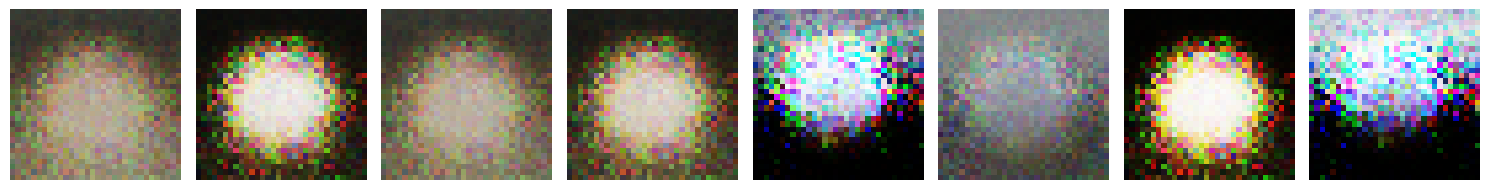

In [ ]:
torch.manual_seed(41)
generator_losses, discriminator_losses = train_gan(generator, discriminator, train_loader, codings_dim)

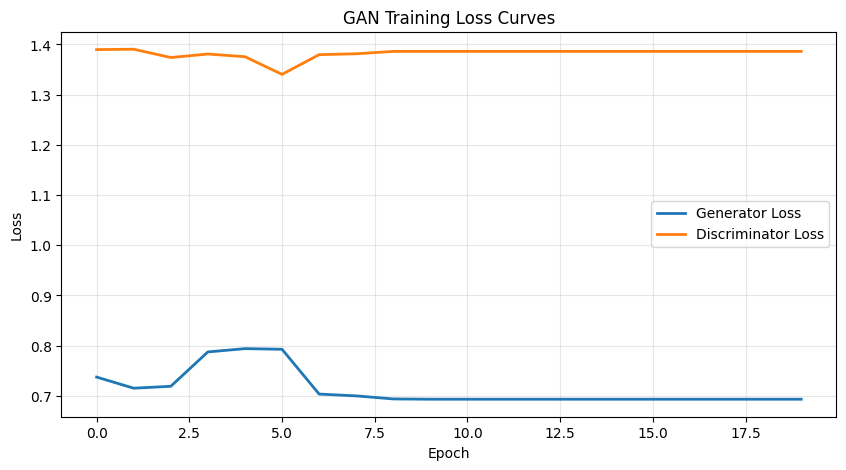

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(generator_losses, label='Generator Loss', linewidth=2)
plt.plot(discriminator_losses, label='Discriminator Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('График изменения функции потерь при каждой эпохе')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

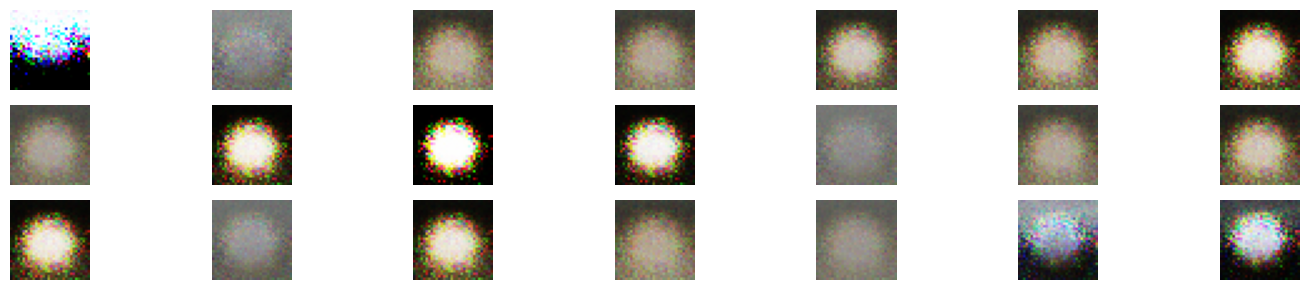

In [ ]:
torch.manual_seed(42)
n_images = 3 * 7
generator.eval()
codings = torch.randn(n_images, codings_dim, device=device)
with torch.no_grad():
    generated_images = generator(codings)
plot_multiple_images(generated_images, 7)

plt.show()